In [31]:
import numpy as np  # Mengimpor library NumPy untuk operasi matematika dan array

def integrate_rec(f, a, b, n):
    # Implementasi metode integral persegi panjang (Rectangle Rule/Riemann Sum)
    h = (b-a)/n                         # Menghitung lebar setiap sub-interval (step size)
    x = np.linspace(a, b, n+1)          # Membuat titik-titik koordinat x dari a sampai b sebanyak n+1 titik
    i = 0                               # Inisialisasi indeks counter mulai dari nol
    area = 0                            # Inisialisasi variabel untuk menyimpan total luas area
    
    while i < n:                        # Melakukan perulangan sebanyak n kali (jumlah persegi panjang)
        sup_rect = f(x[i]) * h          # Menghitung luas satu persegi (Tinggi: f(x) dikali Lebar: h)
        area += sup_rect                # Menambahkan luas persegi tersebut ke total area (akumulasi)
        i += 1                          # Berpindah ke indeks titik x berikutnya
    return area                         # Mengembalikan nilai total hasil integrasi

'''
Uji coba metode Rectangle pada fungsi sinus. 
Integral sin(x) dari 0 sampai pi/2 hasil teoritisnya adalah 1.
'''

# Memanggil fungsi dengan jumlah pembagi (n) yang berbeda-beda
sup_5 = integrate_rec(np.sin, 0, np.pi/2, 5)     # Menghitung dengan 5 persegi panjang
sup_10 = integrate_rec(np.sin, 0, np.pi/2, 10)   # Menghitung dengan 10 persegi panjang
sup_100 = integrate_rec(np.sin, 0, np.pi/2, 100) # Menghitung dengan 100 persegi panjang (lebih akurat)

# Menampilkan hasil ke layar dengan pembulatan 2 angka di belakang desimal
print('Using n=5, the rectangle method returns a value of {:.2f}'.format(sup_5))
print('Using n=10, the rectangle method returns a value of {:.2f}'.format(sup_10))
print('Using n=100, the rectangle method returns a value of {:.2f}'.format(sup_100))


Using n=5, the rectangle method returns a value of 0.83
Using n=10, the rectangle method returns a value of 0.92
Using n=100, the rectangle method returns a value of 0.99


In [32]:
import numpy as np  # Mengimpor library NumPy untuk fungsi matematika (sin, pi)

def integrate_trap(f, a, b, n):
    # Implementasi metode Trapesium untuk integrasi numerik
    h = (b-a)/n                      # Menghitung lebar setiap sub-interval (step size)
    x = np.linspace(a, b, n+1)       # Membuat n+1 titik koordinat dari batas a hingga b
    i = 1                            # Inisialisasi indeks mulai dari titik kedua (indeks 1)
    
    # Menghitung bagian ujung: (f(awal) + f(akhir)) / 2 * h
    area = h * (f(x[0]) + f(x[n])) / 2 
    
    while i < n:                     # Perulangan untuk titik-titik di bagian dalam kurva
        sup_rect = f(x[i]) * h       # Menghitung luas bagian tengah (f(x) * h)
        area += sup_rect             # Menambahkan hasil ke total akumulasi area
        i += 1                       # Pindah ke titik berikutnya
    return area                      # Mengembalikan total nilai integral

'''
Uji coba metode Trapesium pada fungsi sinus. 
Hasil integral sin(x) dari 0 sampai pi/2 adalah tepat 1.00.
'''

# Memanggil fungsi dengan jumlah pembagi (n) yang berbeda
sup_5 = integrate_trap(np.sin, 0, np.pi/2, 5)    # Menghitung dengan 5 trapesium
sup_10 = integrate_trap(np.sin, 0, np.pi/2, 10)  # Menghitung dengan 10 trapesium

# Menampilkan hasil dengan pembulatan 2 angka desimal
print('Using n=5, the trapezoidal rule returns a value of {:.2f}'.format(sup_5))
print('Using n=10, the trapezoidal rule returns a value of {:.2f}'.format(sup_10))


Using n=5, the trapezoidal rule returns a value of 0.99
Using n=10, the trapezoidal rule returns a value of 1.00


In [33]:
import numpy as np              # Mengimpor NumPy untuk pengolahan array dan matematika
from scipy import integrate      # Mengimpor modul integrate dari SciPy untuk rumus numerik

# Membuat 3 titik (x0, x1, x2) dari rentang 0 sampai 9, yang berarti ada n=2 interval
x = np.linspace(0, 9, 3) 
y = x**2                        # Mendefinisikan fungsi y = x^2 (parabola) pada titik-titik x tersebut

# Menggunakan fungsi bawaan NumPy untuk menghitung integral dengan aturan Trapesium
sup_trapz = np.trapezoid(y, x)

# Menggunakan fungsi bawaan SciPy untuk menghitung integral dengan aturan Simpson
sup_simps = integrate.simpson(y, x)

# Menampilkan hasil perhitungan ke layar tanpa angka desimal (.0f)
print('Using n=2, the trapezoidal rule returns a value of {:.0f}'.format(sup_trapz))
print('Using n=2, the composite Simpson rule returns a value of {:.0f}'.format(sup_simps))

'''
Output:
Using n=2, the trapezoidal rule returns a value of 273   # Hasil metode Trapesium
Using n=2, the composite Simpson rule returns a value of 243   # Hasil metode Simpson
'''


Using n=2, the trapezoidal rule returns a value of 273
Using n=2, the composite Simpson rule returns a value of 243


'\nOutput:\nUsing n=2, the trapezoidal rule returns a value of 273   # Hasil metode Trapesium\nUsing n=2, the composite Simpson rule returns a value of 243   # Hasil metode Simpson\n'

In [34]:
import numpy as np                 # Mengimpor NumPy untuk manipulasi data array
from scipy import integrate         # Mengimpor modul integrate dari SciPy untuk metode Simpson

# Array yang berisi luas area pada setiap level kontur (dalam meter persegi)
conturs_areas = np.array([194135, 136366, 79745, 38335, 18450, 9635, 3895])

# Array yang berisi ketinggian/kedalaman (x) untuk setiap kontur (interval 25 meter)
x = np.array([0, 25, 50, 75, 100, 125, 150])

# Menghitung volume menggunakan Aturan Trapesium (menghubungkan luas kontur dengan garis lurus)
vol_traps = np.trapezoid(conturs_areas, x)

# Menghitung volume menggunakan Aturan Simpson (menghubungkan luas kontur dengan kurva parabola)
vol_simps = integrate.simpson(conturs_areas, x)

# Menampilkan hasil perhitungan volume dalam satuan meter kubik tanpa angka desimal
print('The trapezoidal rule returns a volume of {:.0f} cubic meters'.format(vol_traps))
print('The composite Simpson rule returns a volume of {:.0f} cubic meters'.format(vol_simps))

'''
Output:
The trapezoidal rule returns a volume of 9538650 cubic meters   # Hasil metode Trapesium
The composite Simpson rule returns a volume of 9431367 cubic meters   # Hasil metode Simpson
'''


The trapezoidal rule returns a volume of 9538650 cubic meters
The composite Simpson rule returns a volume of 9431367 cubic meters


'\nOutput:\nThe trapezoidal rule returns a volume of 9538650 cubic meters   # Hasil metode Trapesium\nThe composite Simpson rule returns a volume of 9431367 cubic meters   # Hasil metode Simpson\n'

In [35]:
import numpy as np

def simple_lithopress(z, ro=2900, g=9.8):
    # Fungsi menghitung tekanan litostatik (P = z * g * rho)
    # z: Kedalaman (meter)
    # ro: Densitas rata-rata batuan (default 2900 kg/m^3)
    # g: Percepatan gravitasi (default 9.8 m/s^2)
    
    pressure = z * g * ro / 1e6 # Menghitung tekanan dan konversi dari Pascal ke MPa (dibagi 1.000.000)
    return pressure             # Mengembalikan nilai tekanan dalam satuan MPa

# Memanggil fungsi untuk kedalaman 2000 meter
my_pressure = simple_lithopress(z=2000)

# Menampilkan hasil perhitungan dengan format tanpa angka desimal (.0f)
print('The pressure at 2000 meters is {0:.0f} MPa'.format(my_pressure))

'''
Output: 
The pressure at 2000 meters is 57 MPa  # Hasil tekanan pada kedalaman 2 km
'''


The pressure at 2000 meters is 57 MPa


'\nOutput: \nThe pressure at 2000 meters is 57 MPa  # Hasil tekanan pada kedalaman 2 km\n'

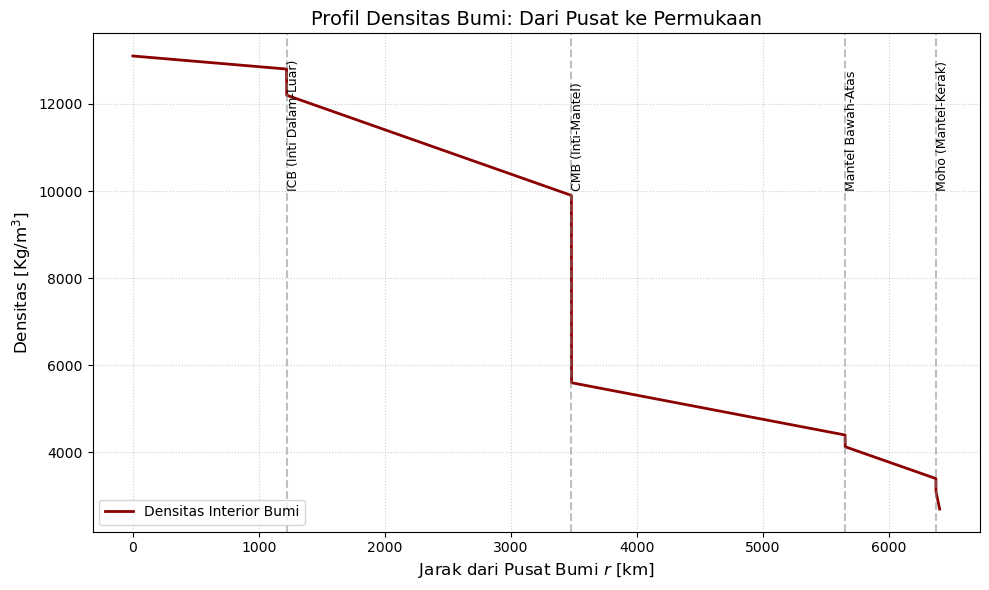

In [36]:
import numpy as np                          # Mengimpor NumPy untuk array dan matematika
from scipy.integrate import trapezoid        # Mengimpor fungsi integrasi trapesium (versi terbaru)
import matplotlib.pyplot as plt             # Mengimpor library untuk membuat grafik

# Membuat array radius dari pusat (1 km) hingga permukaan (6400 km) sebanyak 6400 titik
r = np.linspace(1, 6400, 6400)

def density():
    # Mendefinisikan profil densitas berdasarkan model interior Bumi (mendekati PREM)
    # n_points di sini mewakili ketebalan lapisan dalam km karena r memiliki 6400 titik
    ro_inner_core = np.linspace(13100, 12800, 1220)  # Inti Dalam (Radius 0-1220 km)
    ro_outer_core = np.linspace(12200, 9900, 2259)   # Inti Luar (Radius 1221-3479 km)
    ro_lower_mantle = np.linspace(5600, 4400, 2171)  # Mantel Bawah (Radius 3480-5650 km)
    ro_upper_mantle = np.linspace(4130, 3400, 720)   # Mantel Atas (Radius 5651-6370 km)
    ro_crust = np.linspace(3100, 2700, 30)           # Kerak Bumi (Radius 6371-6400 km)
    
    # Menggabungkan (concatenate) semua potongan lapisan menjadi satu array profil utuh
    ro_final = np.concatenate((ro_inner_core, ro_outer_core, ro_lower_mantle, ro_upper_mantle, ro_crust))
    
    return ro_final

# Memanggil fungsi untuk mendapatkan data densitas (ro)
ro = density()

# --- Pengaturan Visualisasi Grafik ---
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(r, ro, label="Densitas Interior Bumi", color='darkred', linewidth=2)

# Menambahkan keterangan batas lapisan (Garis Putus-Putus)
boundaries = [1220, 3479, 5650, 6370] # Titik transisi antar lapisan
labels = ['ICB (Inti Dalam-Luar)', 'CMB (Inti-Mantel)', 'Mantel Bawah-Atas', 'Moho (Mantel-Kerak)']

for b, l in zip(boundaries, labels):
    ax.axvline(x=b, color='gray', linestyle='--', alpha=0.5) # Membuat garis vertikal abu-abu
    ax.text(b, 10000, l, rotation=90, verticalalignment='bottom', fontsize=9) # Label di grafik

# Memberikan judul dan label sumbu dengan format LaTeX
ax.set_title("Profil Densitas Bumi: Dari Pusat ke Permukaan", fontsize=14)
ax.set_ylabel(r"Densitas [$\text{Kg/m}^3$]", fontsize=12)
ax.set_xlabel("Jarak dari Pusat Bumi $r$ [km]", fontsize=12)

ax.legend()    # Menampilkan legenda
ax.grid(True, linestyle=':', alpha=0.6) # Menampilkan garis kotak-kotak halus

plt.tight_layout()
plt.show()


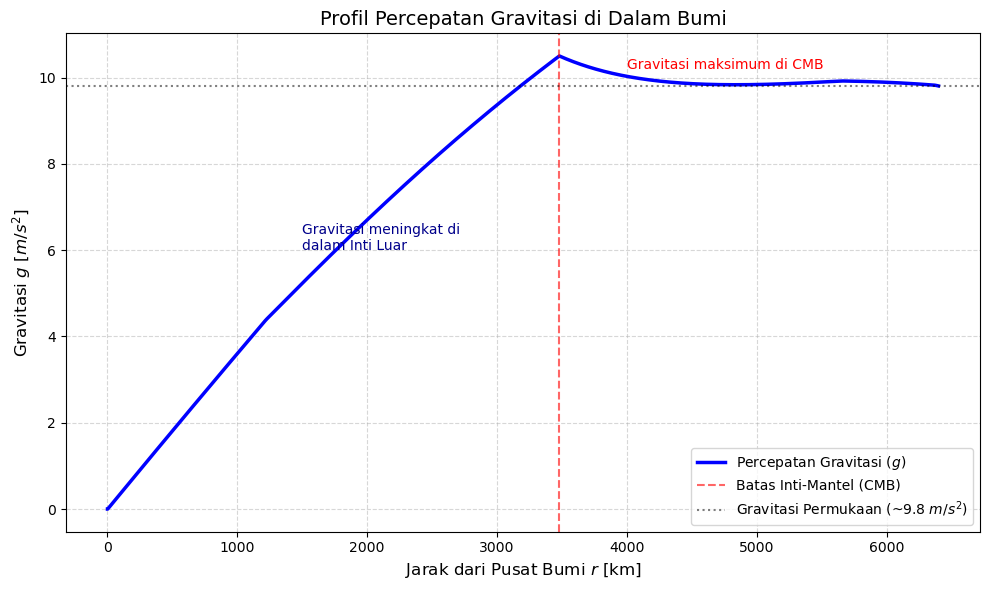

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

def gravity(r, ro):
    # Inisialisasi array g dengan nol
    g = np.zeros(len(r))
    # Konstanta gravitasi universal (m^3 kg^-1 s^-2)
    Gr = 6.67408e-11 
    # Konversi radius dari km ke meter untuk perhitungan SI
    r_m = r * 1000 
    
    # Perulangan untuk menghitung g di setiap titik radius r
    for i in range(1, len(r_m)):
        # Mengambil potongan (slice) radius dan densitas dari pusat hingga titik i
        r_slice = r_m[0:i]
        ro_slice = ro[0:i]
        
        # r_current adalah jarak dari pusat ke titik yang sedang dihitung
        r_current = r_m[i]
    
        # Rumus integral: Massa M(r) = integral dari 4 * pi * rho * r^2 dr
        # Di sini kita integrasikan fungsi (rho * r^2)
        y = ro_slice * r_slice**2
        y_int = trapezoid(y, r_slice)
        
        # Menghitung g menggunakan rumus: g(r) = (4 * pi * G / r^2) * integral(rho * r^2 dr)
        g_val = ((4 * np.pi * Gr) / (r_current**2)) * y_int
        g[i] = g_val
            
    return g

# Menghitung profil gravitasi menggunakan data radius (r) dan densitas (ro) sebelumnya
g_profile = gravity(r, ro)

# --- Visualisasi Grafik yang Diperbarui ---
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(r, g_profile, color='blue', linewidth=2.5, label='Percepatan Gravitasi ($g$)')

# Menambahkan garis bantu untuk batas lapisan utama
ax.axvline(x=3479, color='red', linestyle='--', alpha=0.6, label='Batas Inti-Mantel (CMB)')
ax.axhline(y=9.8, color='black', linestyle=':', alpha=0.5, label='Gravitasi Permukaan (~9.8 $m/s^2$)')

# Menambahkan teks penjelasan
ax.text(1500, 6, "Gravitasi meningkat di\ndalam Inti Luar", fontsize=10, color='darkblue')
ax.text(4000, 10.2, "Gravitasi maksimum di CMB", fontsize=10, color='red')

# Estetika Grafik
ax.set_title("Profil Percepatan Gravitasi di Dalam Bumi", fontsize=14)
ax.set_ylabel(r"Gravitasi $g$ [$m/s^2$]", fontsize=12)
ax.set_xlabel("Jarak dari Pusat Bumi $r$ [km]", fontsize=12)
ax.legend()
ax.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


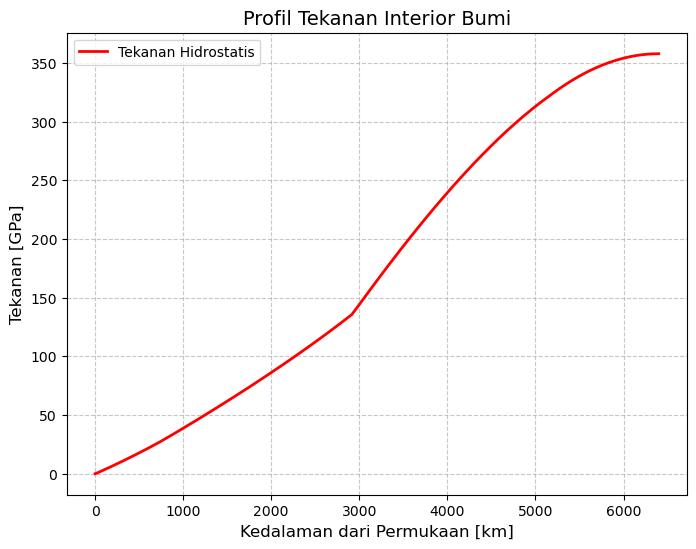

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid

def calculate_pressure(r, ro, g):
    # Konversi r dari km ke meter untuk perhitungan SI (Pascal)
    r_m = r * 1000
    
    # Menghitung integral rho * g dr
    # Kita integrasikan dari permukaan ke arah pusat (atau sebaliknya)
    # y = rho * g
    y = ro * g
    
    # cumulative_trapezoid menghitung integral kumulatif
    # initial=0 memastikan array output memiliki panjang yang sama dengan input
    # Kita gunakan tanda minus karena tekanan meningkat seiring berkurangnya r (kedalaman bertambah)
    p_pa = -cumulative_trapezoid(y, r_m, initial=0)
    
    # Karena integrasi dari pusat ke permukaan akan negatif, kita ambil nilai absolutnya 
    # atau balik urutannya agar tekanan di permukaan (r=6400) adalah 0.
    p_pa = p_pa - p_pa[-1] 
    
    return p_pa / 1e9  # Konversi ke GPa

# Asumsi r, ro, g sudah terdefinisi dari sel sebelumnya
p_gpa = calculate_pressure(r, ro, g)

# Membuat sumbu kedalaman (z) dari permukaan (0 km) ke pusat (6371/6400 km)
z = 6400 - r 

# --- Visualisasi ---
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(z, p_gpa, color='red', linewidth=2, label='Tekanan Hidrostatis')

# Estetika Grafik
ax.set_title("Profil Tekanan Interior Bumi", fontsize=14)
ax.set_xlabel("Kedalaman dari Permukaan [km]", fontsize=12)
ax.set_ylabel("Tekanan [GPa]", fontsize=12)

# Membalik sumbu Y jika ingin menunjukkan kedalaman (opsional)
# ax.invert_yaxis() 

ax.grid(True, linestyle='--', alpha=0.7)
ax.legend()

plt.show()